# dependencias y librerias necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import random

from sklearn.model_selection import train_test_split


# Exploracion y preprocesamiento

Carga de los datos desde el csv y comprobacion mediante head

In [2]:
data = pd.read_csv('full_df.csv')
data.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


se revisa la cantidad de datos

In [3]:
print(f"total len: {len(data)}, len train: {len(data)*0.8}, len test: {len(data)*0.2}")

total len: 6392, len train: 5113.6, len test: 1278.4


Se cuentan los datos agrupados por categoría para ver cómo están distribuidos y revisar posibles desbalances

In [4]:
print(data['labels'].value_counts())

labels
['N']    2873
['D']    1608
['O']     708
['C']     293
['G']     284
['A']     266
['M']     232
['H']     128
Name: count, dtype: int64


In [5]:
print(data.columns)

Index(['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus',
       'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G',
       'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename'],
      dtype='object')


se eliminan las columnas con datos no relevantes para el modelo monomodal de reconocimiento de enfermedades oculares

In [6]:
data = data.drop(columns=['Right-Diagnostic Keywords', 'Left-Diagnostic Keywords', 'Left-Fundus', 'Right-Fundus'])
print(data.head())

   ID  Patient Age Patient Sex  N  D  G  C  A  H  M  O  \
0   0           69      Female  0  0  0  1  0  0  0  0   
1   1           57        Male  1  0  0  0  0  0  0  0   
2   2           42        Male  0  1  0  0  0  0  0  1   
3   4           53        Male  0  1  0  0  0  0  0  1   
4   5           50      Female  0  1  0  0  0  0  0  0   

                                            filepath labels  \
0  ../input/ocular-disease-recognition-odir5k/ODI...  ['N']   
1  ../input/ocular-disease-recognition-odir5k/ODI...  ['N']   
2  ../input/ocular-disease-recognition-odir5k/ODI...  ['D']   
3  ../input/ocular-disease-recognition-odir5k/ODI...  ['D']   
4  ../input/ocular-disease-recognition-odir5k/ODI...  ['D']   

                     target     filename  
0  [1, 0, 0, 0, 0, 0, 0, 0]  0_right.jpg  
1  [1, 0, 0, 0, 0, 0, 0, 0]  1_right.jpg  
2  [0, 1, 0, 0, 0, 0, 0, 0]  2_right.jpg  
3  [0, 1, 0, 0, 0, 0, 0, 0]  4_right.jpg  
4  [0, 1, 0, 0, 0, 0, 0, 0]  5_right.jpg  


se construye ruta a la carpeta “preprocessed_images” que es donde se encuentran las imágenes con las que trabajara el modelo y se comprueba que se tenga acceso.

In [7]:
FILEPATH = "./preprocessed_images"

first_file = os.listdir(FILEPATH)[0]
print(first_file)

0_left.jpg


A continuación se elimina la columna filepath  pues para este proyecto las imágenes se encuentran en un directorio de nombre y ruta diferentes

In [8]:
data = data.drop(columns=['filepath'])
data.head()

,ID,Patient Age,Patient Sex,N,D,G,C,A,H,M,O,labels,target,filename
0,0,69,Female,0,0,0,1,0,0,0,0,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1,0,0,0,0,0,0,0,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,0,1,0,0,0,0,0,1,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,0,1,0,0,0,0,0,1,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,0,1,0,0,0,0,0,0,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [9]:
print(data[(data['filename'] == '518_right.jpg') | (data['filename'] == '518_left.jpg')].values)

[[518 67 'Male' 0 1 0 0 0 0 0 1 "['D']" '[0, 1, 0, 0, 0, 0, 0, 0]'
  '518_right.jpg']]


Se cuenta otra vez los datos por categorías, pero esta vez usando la columna target en lugar de labels, nótese que ambos conteos coinciden

In [10]:
print(data['target'].value_counts()) 

target
[1, 0, 0, 0, 0, 0, 0, 0]    2873
[0, 1, 0, 0, 0, 0, 0, 0]    1608
[0, 0, 0, 0, 0, 0, 0, 1]     708
[0, 0, 0, 1, 0, 0, 0, 0]     293
[0, 0, 1, 0, 0, 0, 0, 0]     284
[0, 0, 0, 0, 1, 0, 0, 0]     266
[0, 0, 0, 0, 0, 0, 1, 0]     232
[0, 0, 0, 0, 0, 1, 0, 0]     128
Name: count, dtype: int64


se agrupan las columnas referentes al diagnóstico en una única columna

In [11]:

data['diagnostic'] = data.apply(lambda row: ''.join([col for col in ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O'] if row[col] == 1]), axis=1)

data = data.drop(columns=['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O'])

data.head()

,ID,Patient Age,Patient Sex,labels,target,filename,diagnostic
0,0,69,Female,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg,C
1,1,57,Male,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg,N
2,2,42,Male,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg,DO
3,4,53,Male,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg,DO
4,5,50,Female,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg,D


se hace conteo de los diagnósticos que difiere de el de las etiquetas pues el primero se refiere a los 2 ojos y el segundo únicamente a uno

In [12]:
print(data['diagnostic'].value_counts())

diagnostic
N      2101
D      1376
O       894
DO      464
C       276
A       234
G       232
M       206
DH       88
H        72
DC       62
GO       57
MO       51
DG       42
CO       42
DA       28
DM       26
AO       23
GA       19
HO       15
DGO      12
DCO      12
GM       10
GH       10
AH        8
DMO       6
GHO       5
CH        4
GC        4
GCO       2
DAM       2
DGM       2
DAO       2
AM        2
GMO       1
DHO       1
GAO       1
Name: count, dtype: int64


Se revisa que se pueda acceder a los datos a través de la columna diagnostico

In [13]:
print(data[data['diagnostic'] == 'GAO'])


        ID  Patient Age Patient Sex labels                    target  \
4550  2041           55      Female  ['G']  [0, 0, 1, 0, 0, 0, 0, 0]   

           filename diagnostic  
4550  2041_left.jpg        GAO  


se filtran a los pacientes de los que solo se tiene la fotografía de un ojo y posterior mente se cuentan

In [14]:
id_counts = data['ID'].value_counts()
id_counts[id_counts != 2].index.tolist()


[92,
 41,
 4601,
 147,
 4551,
 124,
 59,
 155,
 197,
 138,
 63,
 70,
 4427,
 4394,
 154,
 4319,
 151,
 69,
 2515,
 202,
 866,
 2107,
 839,
 2053,
 842,
 2041,
 2010,
 1968,
 2159,
 1965,
 1716,
 1710,
 867,
 887,
 1662,
 836,
 830,
 900,
 2428,
 757,
 760,
 2477,
 762,
 770,
 2448,
 804,
 2229,
 806,
 817,
 2377,
 2350,
 827,
 2241,
 895,
 1643,
 241,
 994,
 1274,
 984,
 1228,
 25,
 1162,
 1156,
 1137,
 1369,
 1020,
 1123,
 1096,
 1065,
 1089,
 1095,
 982,
 1442,
 1640,
 920,
 914,
 1638,
 1628,
 1626,
 1598,
 915,
 944,
 1456,
 956,
 1591,
 969,
 1571,
 975,
 1566,
 736,
 2478,
 734,
 4066,
 4091,
 429,
 432,
 440,
 444,
 459,
 467,
 426,
 493,
 4058,
 529,
 3947,
 536,
 3398,
 4124,
 4180,
 721,
 4219,
 246,
 267,
 4262,
 290,
 307,
 4243,
 317,
 395,
 320,
 328,
 4198,
 346,
 362,
 372,
 3369,
 3325,
 539,
 2721,
 651,
 658,
 659,
 2729,
 2727,
 2724,
 2664,
 3292,
 2546,
 670,
 2516,
 671,
 683,
 716,
 633,
 2747,
 620,
 606,
 600,
 2757,
 2831,
 595,
 2968,
 3019,
 3021,
 3049,
 3

In [15]:
print(len(id_counts[id_counts != 2]))

324


Se revisa el tipo de datos en cada categoria

In [16]:
print(data.dtypes)
data['target'] = data['target'].apply(lambda x: list(map(int, x.strip('[]').split(','))))

ID              int64
Patient Age     int64
Patient Sex    object
labels         object
target         object
filename       object
diagnostic     object
dtype: object


Se transforma el vector objetivo en un entero que hace referencia a la posición en la que está la categoría deseada

In [17]:
data['target'] = data['target'].apply(lambda x: x.index(1))
data = data.drop(columns=['labels'])
print(data.head())

   ID  Patient Age Patient Sex  target     filename diagnostic
0   0           69      Female       0  0_right.jpg          C
1   1           57        Male       0  1_right.jpg          N
2   2           42        Male       1  2_right.jpg         DO
3   4           53        Male       1  4_right.jpg         DO
4   5           50      Female       1  5_right.jpg          D


In [18]:
classes = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
classes

['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

In [19]:
classes_details = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract', 'Age-related Macular Degeneration', 'Hypertension', 'Myopia', 'Other'] 

In [20]:
data.to_csv('preprocessed_data.csv', index=False)

# Visualization

In [21]:
RED = '#f54242'
BLUE = '#42c8f5'

Se extraen los datos de objetivo y sexo y se grafican, notamos que para la cantidad de datos masculinos es ligeramente mayor pero aun así la población femenina tiene mayor representación en algunas enfermedades, lo que podría señalar que son mas propensas a estas,

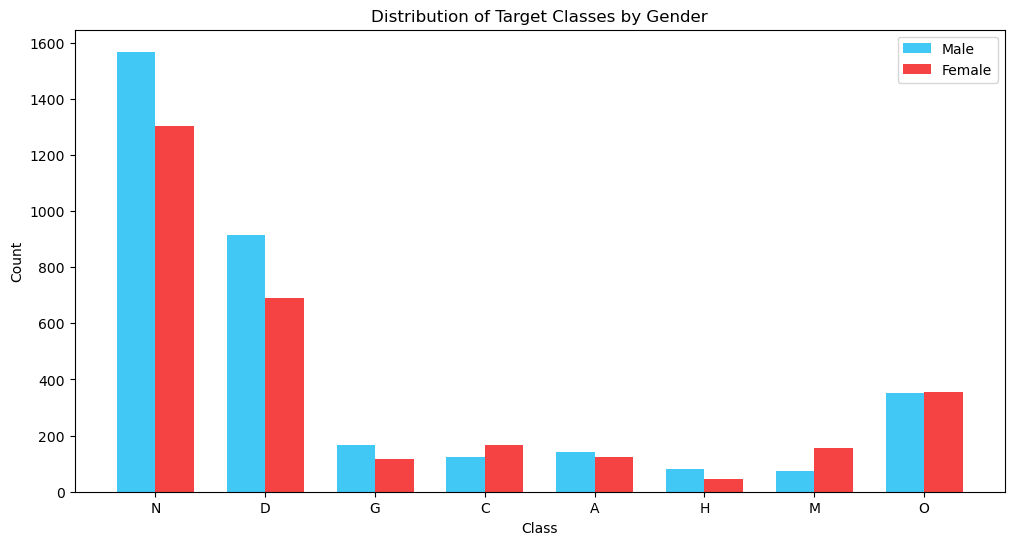

In [22]:
male_counts = data[data['Patient Sex'] == 'Male']['target'].value_counts().sort_index()
female_counts = data[data['Patient Sex'] == 'Female']['target'].value_counts().sort_index()

male_counts = male_counts.reindex(range(len(classes)), fill_value=0)
female_counts = female_counts.reindex(range(len(classes)), fill_value=0)

bar_width = 0.35
index = np.arange(len(classes))

plt.figure(figsize=(12, 6))
plt.bar(index, male_counts, bar_width, label='Male', color=BLUE)
plt.bar(index + bar_width, female_counts, bar_width, label='Female', color=RED)

plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of Target Classes by Gender')
plt.xticks(index + bar_width / 2, classes)
plt.legend()

plt.show()

A continuación se grafican los pacientes sin enfermedades oculares con todos los demás para ver cuál es la relación entre ojos sanos y afectados por alguna enfermedad 

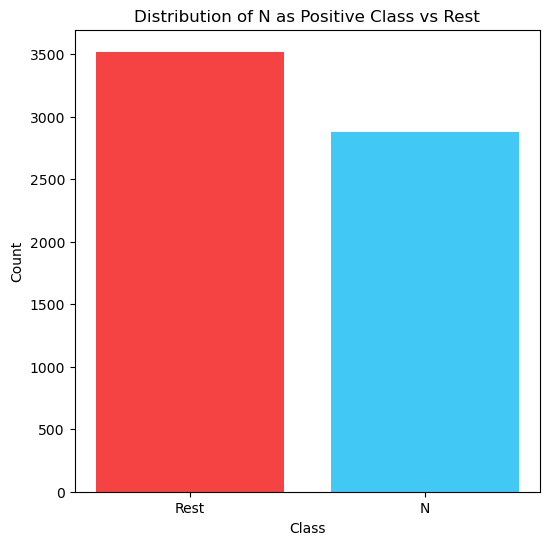

In [23]:
data['binary_target'] = data['target'].apply(lambda x: 1 if x == 0 else 0)

binary_counts = data['binary_target'].value_counts()

plt.figure(figsize=(6, 6))
plt.bar(['Rest', 'N'], binary_counts, color=[RED, BLUE])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Distribution of N as Positive Class vs Rest')
plt.show()

También se grafica la distribución de edades de los pacientes, notando mayor cantidad alrededor de los 60 años.

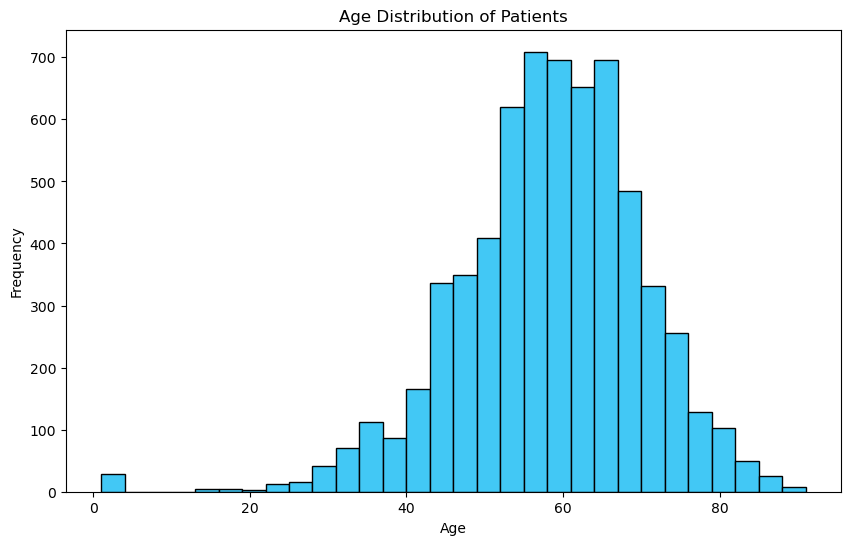

In [24]:
plt.figure(figsize=(10, 6))
plt.hist(data['Patient Age'], bins=30, color=BLUE, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Patients')
plt.show()

Se grafica la distribución de sexo de los pacientes

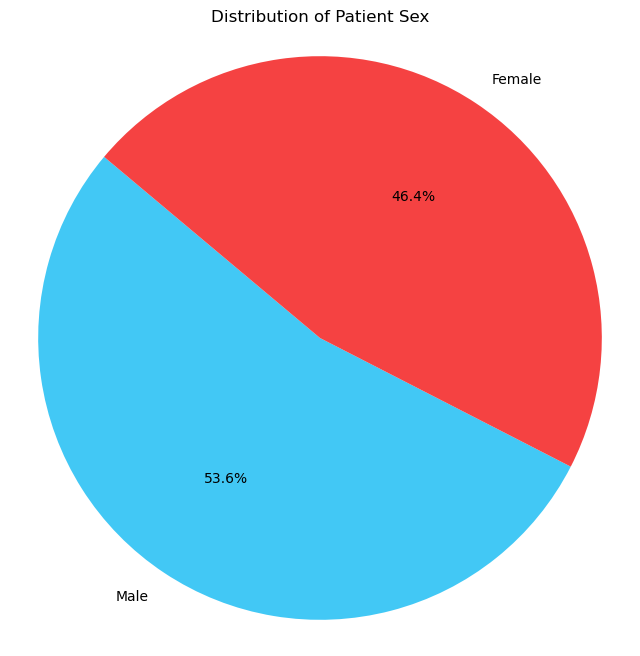

In [25]:
sex_counts = data['Patient Sex'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', colors=[BLUE, RED], startangle=140)
plt.title('Distribution of Patient Sex')
plt.axis('equal') 
plt.show()

A continuación, se muestra un ejemplo de 10 imágenes por categoría

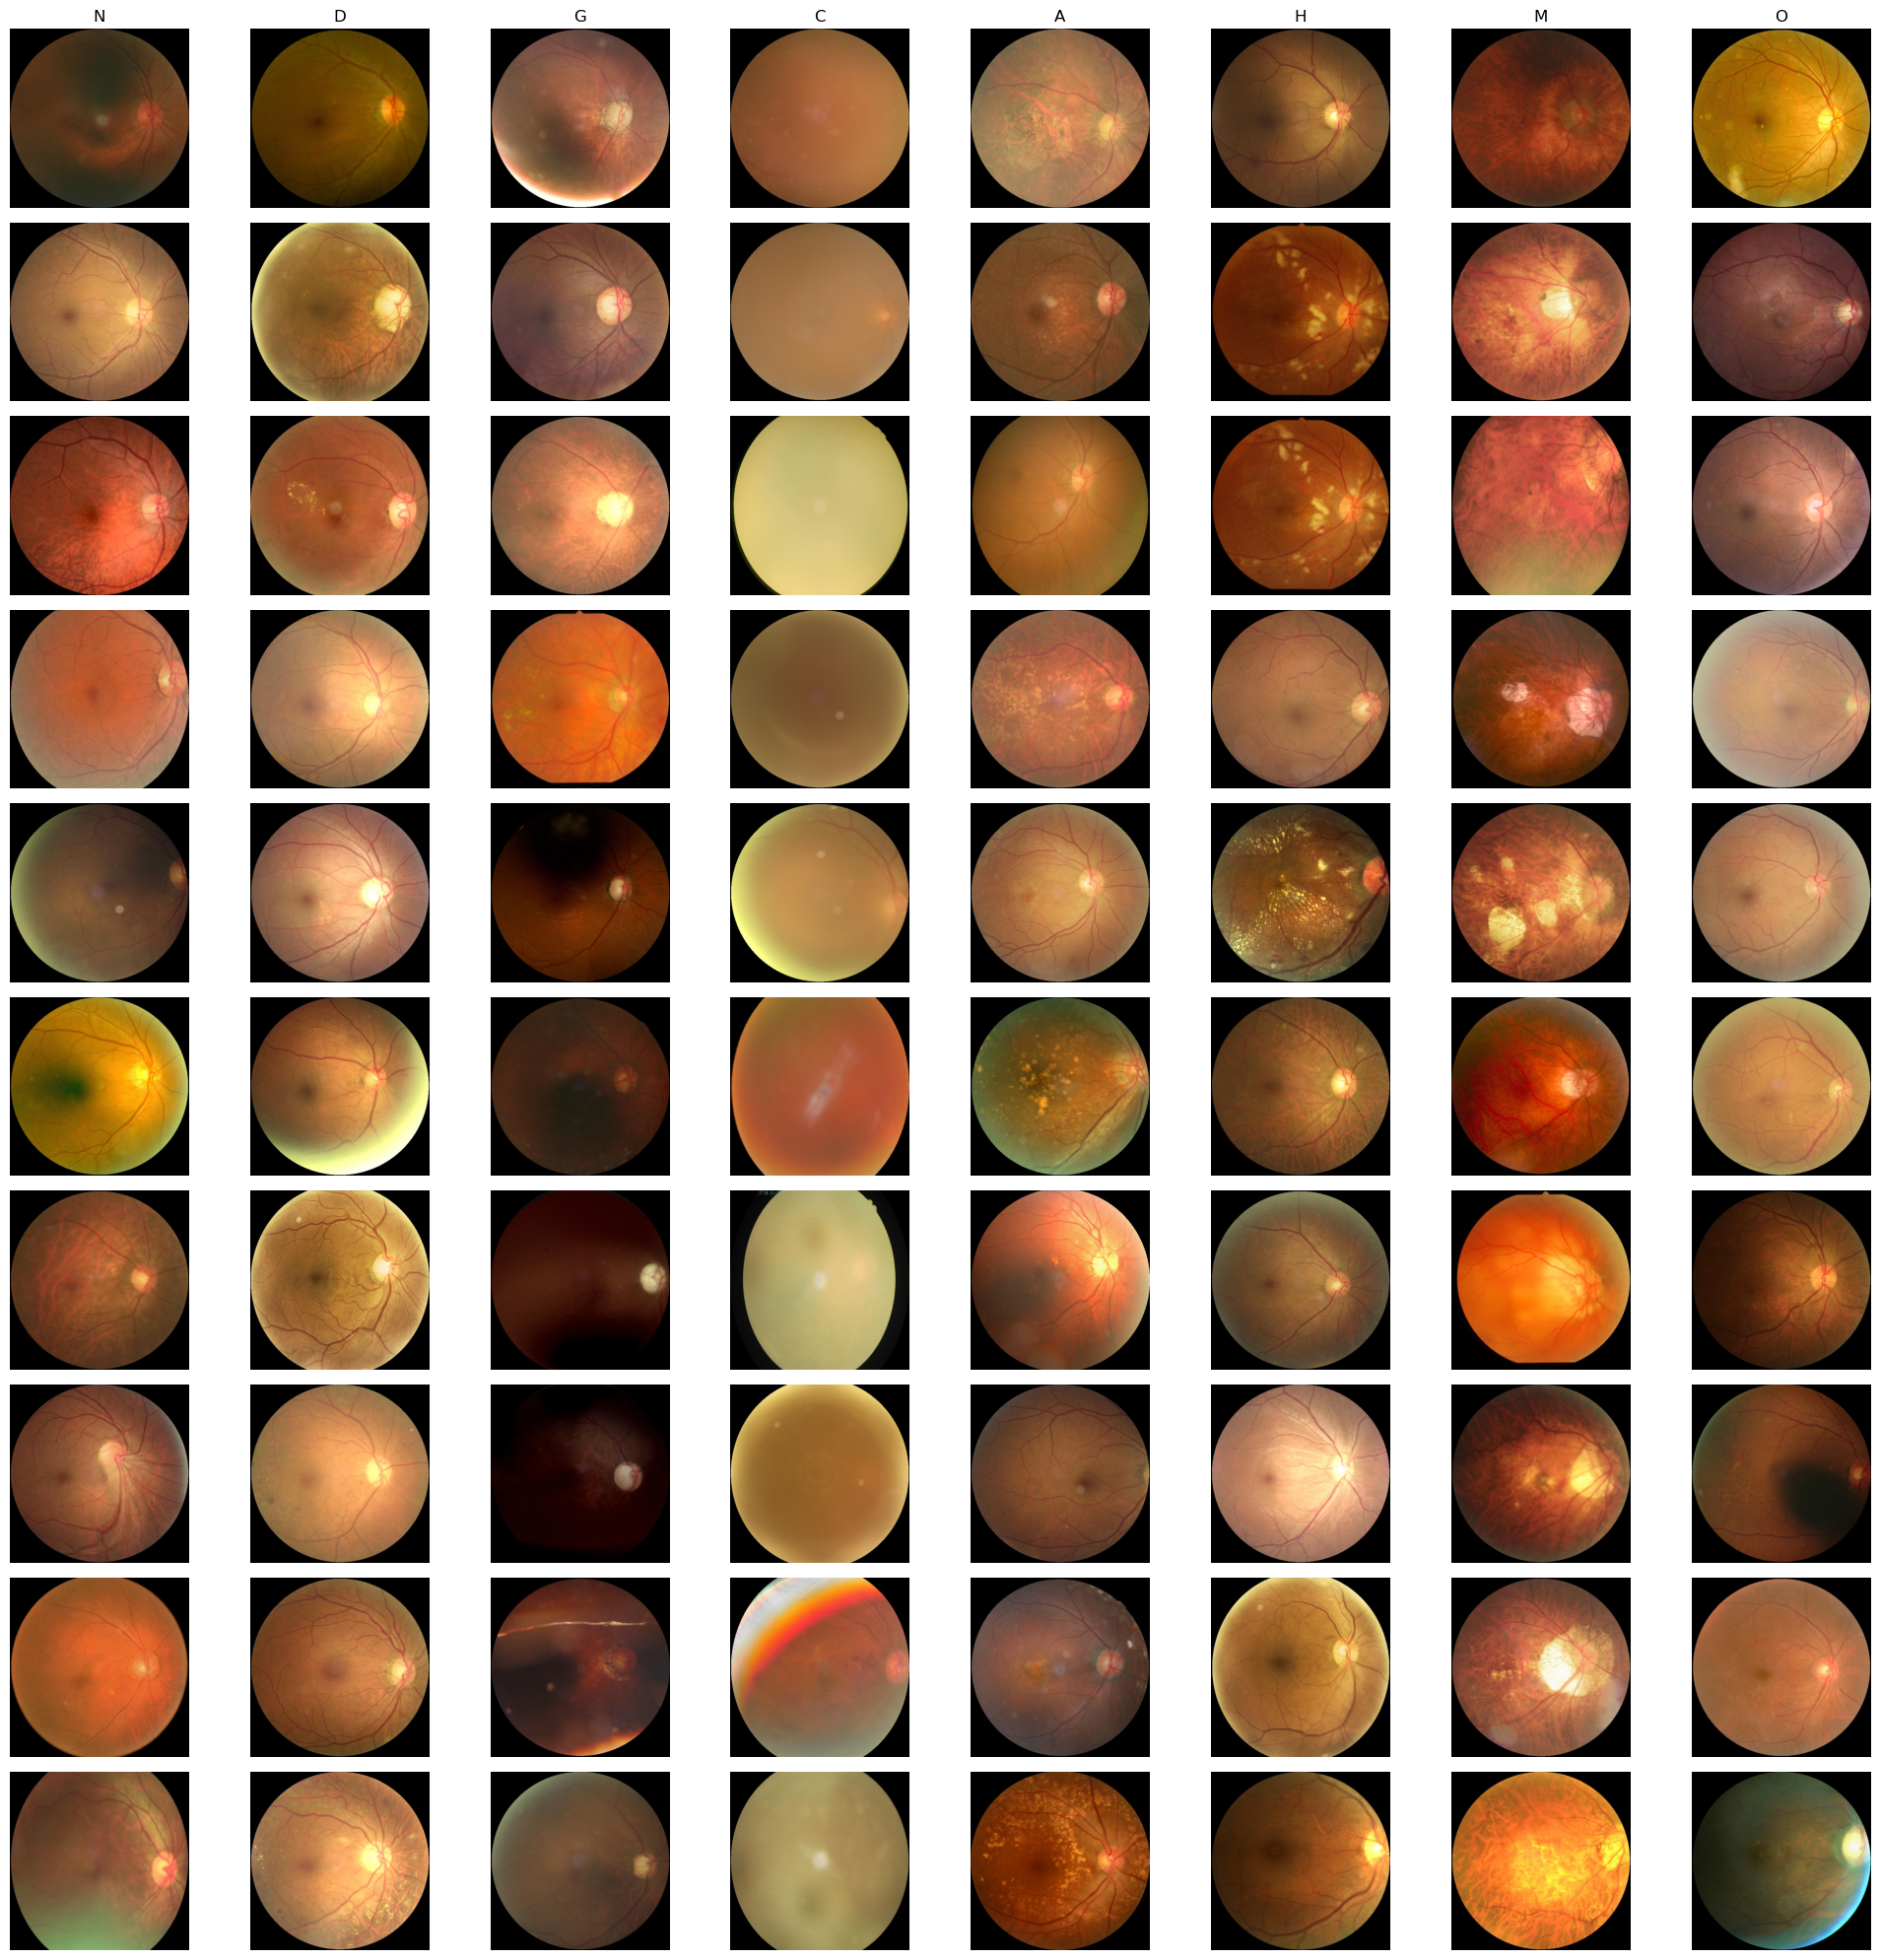

In [26]:
fig, axes = plt.subplots(nrows=10, ncols=len(classes), figsize=(20, 20))

for i, cls in enumerate(classes):
    class_images = data[data['target'] == i]['filename'].head(10)
    for j, img_name in enumerate(class_images):
        img_path = os.path.join(FILEPATH, img_name)
        img = plt.imread(img_path)
        axes[j, i].imshow(img)
        axes[j, i].axis('off')
        if j == 0:
            axes[j, i].set_title(cls)

plt.tight_layout()
plt.show()

A continuación, se ven los dos ojos de un paciente

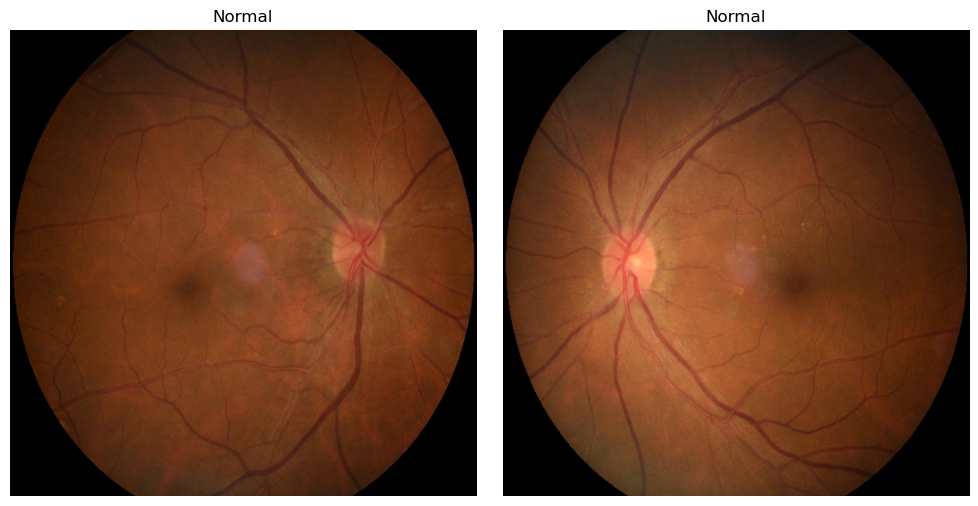

In [27]:
excluded_ids = id_counts[id_counts != 2].index.tolist()
valid_data = data[~data['ID'].isin(excluded_ids)]

random_id = random.choice(valid_data['ID'].unique())

patient_images = valid_data[valid_data['ID'] == random_id]['filename'].tolist()
patient_classes = valid_data[valid_data['ID'] == random_id]['target'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, (img_name, cls) in enumerate(zip(patient_images, patient_classes)):
    img_path = os.path.join(FILEPATH, img_name)
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(classes_details[cls])

plt.tight_layout()
plt.show()

Se revisan las dimensiones de las imagenes

In [28]:
for img_name in data['filename'].head(10): 
    img_path = os.path.join(FILEPATH, img_name)
    img = plt.imread(img_path)
    print(f"Image: {img_name}, Dimensions: {img.shape}")

Image: 0_right.jpg, Dimensions: (512, 512, 3)
Image: 1_right.jpg, Dimensions: (512, 512, 3)
Image: 2_right.jpg, Dimensions: (512, 512, 3)
Image: 4_right.jpg, Dimensions: (512, 512, 3)
Image: 5_right.jpg, Dimensions: (512, 512, 3)
Image: 6_right.jpg, Dimensions: (512, 512, 3)
Image: 7_right.jpg, Dimensions: (512, 512, 3)
Image: 8_right.jpg, Dimensions: (512, 512, 3)
Image: 9_right.jpg, Dimensions: (512, 512, 3)
Image: 10_right.jpg, Dimensions: (512, 512, 3)


se revisan las imágenes con forma diferente a la estandar

In [29]:
for img_name in data['filename']:
    img_path = os.path.join(FILEPATH, img_name)
    img = plt.imread(img_path)
    if img.shape != (512, 512, 3):
        print(f"Image: {img_name}, Dimensions: {img.shape}")

se dividen los datos en entrenamiento y prueba

In [30]:
train_data, test_data = train_test_split(data, test_size=0.2, stratify=data['target'], random_state=511) #OCT 5TH

print(f"Train data length: {len(train_data)}")
print(f"Test data length: {len(test_data)}")

Train data length: 5113
Test data length: 1279


se guardan como en formato h5 las bases de datos para prueba  y entrenamiento

In [31]:
train_data.to_hdf('train_data.h5', key='train', mode='w')
test_data.to_hdf('test_data.h5', key='test', mode='w')